In [1]:
%reset -f

# load all packages

In [2]:
import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd
import statsmodels.api   as sm
import statsmodels.formula.api as smf # for easier interaction estimation
import seaborn as sns

# load data into Python

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Michael-Morgan-Giles/python-causality-handbook/refs/heads/master/causal-inference-for-the-brave-and-true/data/smoking.csv")

# check the head of your table

In [4]:
df.head()

,state,year,cigsale,lnincome,beer,age15to24,retprice,california,after_treatment
0,1,1970,89.800003,NaN,NaN,0.178862,39.599998,False,False
1,1,1971,95.400002,NaN,NaN,0.179928,42.700001,False,False
2,1,1972,101.099998,9.498476,NaN,0.180994,42.299999,False,False
3,1,1973,102.900002,9.550107,NaN,0.182060,42.099998,False,False
4,1,1974,108.199997,9.537163,NaN,0.183126,43.099998,False,False


In [5]:
df.shape

(1209, 9)

# add constant term

In [6]:
df = sm.add_constant(df)

create necessary variables

In [7]:
df['treated'] = np.where(df['california'] == True,1,0)
df['post_treat'] = np.where(df['after_treatment'] == True,1,0)
df['int_for_now'] = df['treated']*df['post_treat']
df = pd.concat([df,pd.get_dummies(df['year'], prefix = "year").astype(int)], axis = 1)

# check the summary statistics

In [8]:
df.describe()

,const,state,year,cigsale,lnincome,beer,age15to24,retprice,treated,post_treat,...,year_1991,year_1992,year_1993,year_1994,year_1995,year_1996,year_1997,year_1998,year_1999,year_2000
count,1209.0,1209.000000,1209.000000,1209.000000,1014.000000,546.000000,819.000000,1209.000000,1209.000000,1209.000000,...,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000
mean,1.0,20.000000,1985.000000,118.893218,9.861634,23.430403,0.175472,108.341936,0.025641,0.387097,...,0.032258,0.032258,0.032258,0.032258,0.032258,0.032258,0.032258,0.032258,0.032258,0.032258
std,0.0,11.259286,8.947973,32.767404,0.170677,4.223190,0.015159,64.381986,0.158127,0.487288,...,0.176758,0.176758,0.176758,0.176758,0.176758,0.176758,0.176758,0.176758,0.176758,0.176758
min,1.0,1.000000,1970.000000,40.700001,9.397449,2.500000,0.129448,27.299999,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.0,10.000000,1977.000000,100.900002,9.739134,20.900000,0.165816,50.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.0,20.000000,1985.000000,116.300003,9.860844,23.299999,0.178121,95.500000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.0,30.000000,1993.000000,130.500000,9.972764,25.100000,0.186660,158.399994,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.0,39.000000,2000.000000,296.200012,10.486617,40.400002,0.203675,351.200012,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# check variable names

In [9]:
df.columns

Index(['const', 'state', 'year', 'cigsale', 'lnincome', 'beer', 'age15to24',
       'retprice', 'california', 'after_treatment', 'treated', 'post_treat',
       'int_for_now', 'year_1970', 'year_1971', 'year_1972', 'year_1973',
       'year_1974', 'year_1975', 'year_1976', 'year_1977', 'year_1978',
       'year_1979', 'year_1980', 'year_1981', 'year_1982', 'year_1983',
       'year_1984', 'year_1985', 'year_1986', 'year_1987', 'year_1988',
       'year_1989', 'year_1990', 'year_1991', 'year_1992', 'year_1993',
       'year_1994', 'year_1995', 'year_1996', 'year_1997', 'year_1998',
       'year_1999', 'year_2000'],
      dtype='str')

## Plots

series plots n wat not

/tmp/ipykernel_60718/3647880771.py:2: UserWarning: 
The palette list has fewer values (6) than needed (38) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(y = "cigsale",


Text(0.5, 1.0, 'Historical Cigarette Sales Per Capita by State')

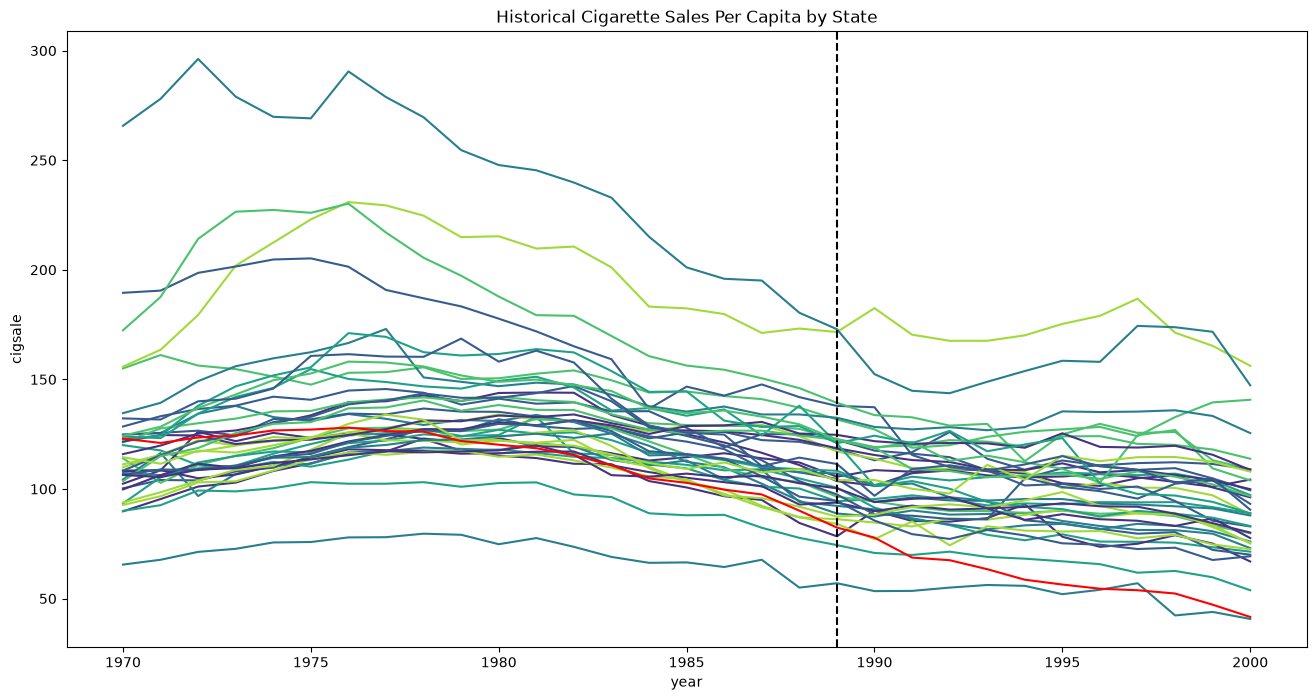

In [10]:
plt.figure(figsize = (16,8))
sns.lineplot(y = "cigsale", 
            x = "year",
            hue = "state",
            data = df[df['california'] == False],
            palette = sns.color_palette("viridis"),
            legend = False)
plt.plot(df[df['california'] == True]['year'], df[df['california'] == True]['cigsale'], color = "red")
plt.axvline(x = 1989, color = "black", linestyle = "--")
plt.title("Historical Cigarette Sales Per Capita by State")
#plt.subtitle("Solid black line is california")

# Modelling 

...

In [11]:
print(sm.OLS(df[['cigsale']], 
            df[['const',
                'treated',
                'post_treat',
                'int_for_now']], 
           missing = "drop").fit(cov_type = "HC3").summary())

                            OLS Regression Results                            
Dep. Variable:                cigsale   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     172.0
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           8.16e-93
Time:                        17:23:13   Log-Likelihood:                -5793.3
No. Observations:                1209   AIC:                         1.159e+04
Df Residuals:                    1205   BIC:                         1.161e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         130.5695      1.218    107.224      

In [12]:
print(smf.ols('cigsale ~ treated * post_treat', 
              data = df,
           missing = "drop").fit(cov_type = "HC3").summary())

                            OLS Regression Results                            
Dep. Variable:                cigsale   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     172.0
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           8.16e-93
Time:                        17:23:13   Log-Likelihood:                -5793.3
No. Observations:                1209   AIC:                         1.159e+04
Df Residuals:                    1205   BIC:                         1.161e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            130.5695      1

# Event Design Study

....


In [13]:
import linearmodels as lm

# create year interaction
treated_cols = [col for col in pd.get_dummies(df['year'], prefix='year', drop_first=False).columns]
for col in treated_cols:
    df[f'treated_{col}'] = df['treated'] * df[col]

 # remove the intervention year to act as a baseline
interaction_terms = [f'treated_{col}' for col in treated_cols if col != 'year_1988']

# set unit and time dimensions
panel = df.set_index(['state', 'year'])

In [14]:
event_mod = lm.PanelOLS.from_formula(f"cigsale ~ {' + '.join(interaction_terms)} + EntityEffects + TimeEffects",
                         data = panel, drop_absorbed=True).fit(cov_type = 'clustered',cluster_entity = True)
print(event_mod.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                cigsale   R-squared:                        0.0430
Estimator:                   PanelOLS   R-squared (Between):             -0.0004
No. Observations:                1209   R-squared (Within):               0.0413
Date:                Fri, Jun 19 2026   R-squared (Overall):              0.0007
Time:                        17:23:13   Log-likelihood                   -4657.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.6638
Entities:                          39   P-value                           0.0142
Avg Obs:                       31.000   Distribution:                 F(30,1110)
Min Obs:                       31.000                                           
Max Obs:                       31.000   F-statistic (robust):             37.992
                            

In [15]:
# make plot using params ...s
event_results = pd.merge(pd.DataFrame(event_mod.params).reset_index(), 
                         pd.DataFrame(event_mod.std_errors).reset_index(), 
                         how = "inner", 
                         on = "index").rename (columns = {"index" : "year"})

crit_value = 1.96
event_results["year"] = event_results['year'].str[-4:].astype(int)
event_results["upper"] = event_results["parameter"]  + crit_value * event_results["std_error"] 
event_results["lower"] = event_results["parameter"]  - crit_value * event_results["std_error"]

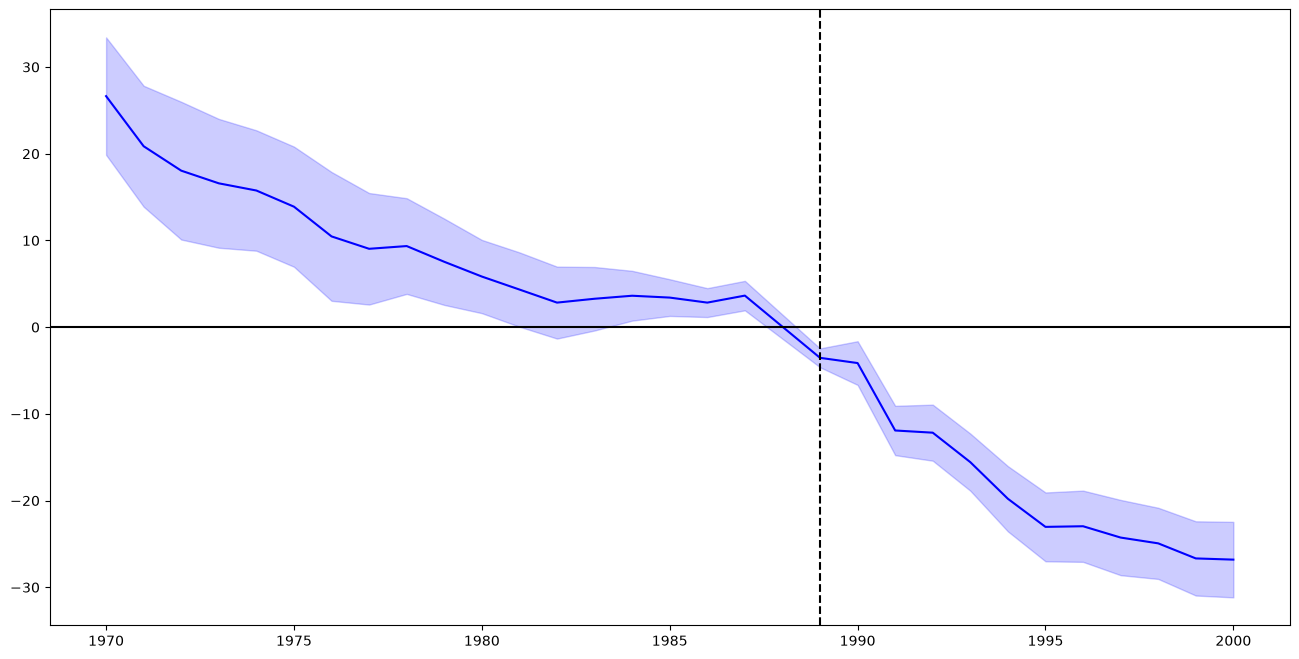

In [16]:
plt.figure(figsize = (16,8))
plt.plot(event_results['year'], event_results["parameter"], color = "blue")
plt.fill_between(event_results['year'], 
                 event_results['lower'], 
                 event_results['upper'], color = "blue", alpha = 0.2)
plt.axvline(x = 1989, color = "black", linestyle = "--")
plt.axhline(y = 0, color = "black", linestyle = "-")